##### Next Step:
- Tabelle anreichern: origin-dest, travel time per 1000 km

##### Perspektivisch:
- Automatisierung der Datensammlung (wahrscheinlich nicht möglich)
- Automatisierung der Datenbereinigung

In [30]:
import json
import pandas as pd
import datetime 
import matplotlib.pyplot as plt
from pathlib import Path
import re


##### Load raw data

In [57]:
folder_path = Path("D:/Datenprojekte/Postcrossing/data/raw")
file_paths = folder_path.glob("*.json")

df_list = []




In [56]:
filepath = Path("D:/Datenprojekte/Postcrossing/data/raw/received_RU_Nataliya_20260117.json")

with open(filepath, "r", encoding="utf-8") as f:
    data = json.load(f)

columnnames = ["postcard_id",
        "user",
        "unknown",
        "country_id_dest",
        "sent_date",
        "received_date",
        "distance_km",
        "travel_time_days",
        "image_exists"
        ]

df_temp = pd.DataFrame(data, columns=columnnames)
#df_temp[0:100]

#df_temp[df_temp["postcard_id"] == "PT-792568"]
df_temp[df_temp["user"] == "cadeteana"]

,postcard_id,user,unknown,country_id_dest,sent_date,received_date,distance_km,travel_time_days,image_exists
9711,PT-790438,cadeteana,0,PT,1688501447,1690835688,3989,27,1


In [58]:
try:
    for file in file_paths:
    
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        columnnames = ["postcard_id",
        "user",
        "unknown",
        "country_id_dest",
        "sent_date",
        "received_date",
        "distance_km",
        "travel_time_days",
        "image_exists"
        ]

        df_temp = pd.DataFrame(data, columns=columnnames)

        if "received" in file.name.lower():
            parts = file.stem.split("_")
            if len(parts) >= 3:
                df_temp["country_id_dest"] = parts[1].upper()

        df_temp["sent_date"] = pd.to_datetime(df_temp["sent_date"], unit="s").dt.normalize()
        df_temp["received_date"] = pd.to_datetime(df_temp["received_date"], unit="s").dt.normalize()
        df_temp["country_id_origin"] = df_temp["postcard_id"].str.split("-", expand=True)[0]
        df_temp["travel_speed"] = (df_temp["travel_time_days"] / df_temp["distance_km"]) * 1000
        df_temp["travel_route"] = df_temp.country_id_origin + "-" + df_temp.country_id_dest
        df_temp = df_temp.drop(columns=["unknown", "user", "image_exists"])

        df_list.append(df_temp)
    

except FileNotFoundError:
    print(f"File not found: {file}")
except json.JSONDecodeError:
    print(f"Error decoding JSON from file: {file}")
except Exception as e:
    print(f"An error occurred: {e}")

In [59]:
# Concatenating dataframes

if df_list:
    df_all = pd.concat(df_list, ignore_index=True)
    df_all = df_all.drop_duplicates(subset=["postcard_id"])
    df_all = df_all.drop(columns=["postcard_id"])
    print(f"Combined dataframe built with {len(df_all)} records and following columns: {df_all.columns}.")
else:
    print("No dataframes to combine.")


Combined dataframe built with 1275506 records and following columns: Index(['country_id_dest', 'sent_date', 'received_date', 'distance_km',
       'travel_time_days', 'country_id_origin', 'travel_speed',
       'travel_route'],
      dtype='object').


In [49]:
print(df_all['country_id_dest'].value_counts().head(10))
df_all.head(10)

country_id_dest
DE    300921
US    190105
FI    135796
NL    129345
RU    113588
CA     86821
CN     26325
BY     21663
CZ     21213
TW     19700
Name: count, dtype: int64


,country_id_dest,sent_date,received_date,distance_km,travel_time_days,country_id_origin,travel_speed,travel_route
0,CA,2021-10-24,2021-11-08,9990,16,AE,1.601602,AE-CA
1,CA,2024-04-19,2024-05-15,9535,26,AF,2.726796,AF-CA
2,CA,2016-03-06,2016-03-30,8040,24,AM,2.985075,AM-CA
3,CA,2016-10-11,2016-11-05,9072,25,AR,2.755732,AR-CA
4,CA,2010-06-27,2010-07-11,5618,14,AT,2.491990,AT-CA
5,CA,2011-07-09,2011-08-19,5701,41,AT,7.191721,AT-CA
6,CA,2013-08-18,2013-08-26,5485,9,AT,1.640839,AT-CA
7,CA,2013-08-26,2013-10-16,5654,52,AT,9.197029,AT-CA
8,CA,2014-08-07,2014-08-14,5756,7,AT,1.216122,AT-CA
9,CA,2014-09-22,2014-12-01,5614,70,AT,12.468828,AT-CA


In [65]:
df_filt = df_all.groupby("country_id_origin").filter(lambda x: len(x) >= 1000)
df_filt.groupby("country_id_origin")["travel_speed"].describe().sort_values(by="mean", ascending=True).head(20)

#df_all[df_all["travel_route"] == "PT-GR"]

,count,mean,std,min,25%,50%,75%,max
country_id_origin,,,,,,,,
NZ,1704.0,1.443893,1.328515,0.267652,0.713766,1.077666,1.690127,18.577189
AU,6419.0,1.535600,1.608482,0.121175,0.724685,1.146712,1.811068,37.573806
SG,2902.0,2.017580,2.863261,0.098251,0.962835,1.357642,2.036462,80.010562
JP,16976.0,2.315772,4.748453,0.236490,0.987898,1.429011,2.186122,163.538874
TH,2186.0,2.736540,3.243540,0.220872,1.243809,1.874813,2.977211,52.917724
HK,6440.0,2.783994,5.837370,0.000000,1.195392,1.722282,2.756617,235.049834
MY,5002.0,3.192794,3.510237,0.000000,1.563856,2.229993,3.593971,93.750000
ID,3120.0,3.199271,3.172231,0.179372,1.605426,2.239997,3.502616,34.583291
TW,28995.0,3.299083,7.224736,0.096684,1.356389,1.967858,3.141480,319.790301


#### Filtering on selected country 

In [67]:
receiving_country = "US"

df_filtered = df_all[df_all["country_id_dest"] == receiving_country]
df_filtered.country_id_origin.value_counts().head(10)

country_id_origin
US    44651
DE    34437
RU    19969
NL    14915
FI    13947
AT     9619
CN     5714
TW     4891
BY     3974
JP     3509
Name: count, dtype: int64

#### DAY - Aggregation

In [31]:
df_daily_travel_time = df_filtered.groupby("sent_date")["travel_time_days"].mean().reset_index()
df_daily_travel_time.rename(columns={"travel_time_days": "avg_travel_time_days"}, inplace=True)

daily_counts = df_filtered.groupby("sent_date").size().reset_index(name="num_postcards_sent")
daily_data = pd.merge(df_daily_travel_time, daily_counts, on="sent_date")


daily_data.head(20)

,sent_date,avg_travel_time_days,num_postcards_sent
0,2006-08-04,9.0,1
1,2006-08-13,4.0,1
2,2006-08-18,11.0,1
3,2006-08-29,25.0,1
4,2006-10-05,9.0,1
5,2006-10-14,31.0,1
6,2006-11-14,11.0,1
7,2006-12-25,80.0,1
8,2007-02-08,36.0,1
9,2007-03-06,15.0,1


#### DAY - Plot

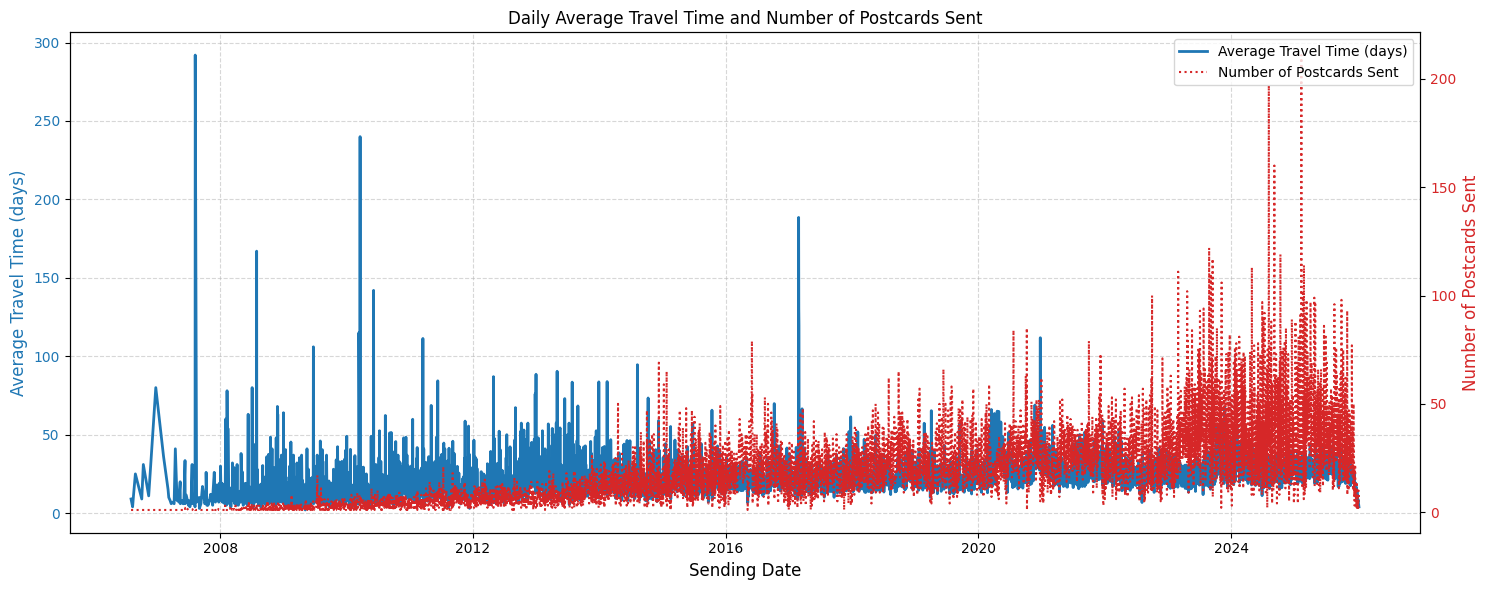

In [32]:
fig, ax1 = plt.subplots(figsize=(15,6))

color1 = "tab:blue"
ax1.set_xlabel("Sending Date", fontsize=12)
ax1.set_ylabel("Average Travel Time (days)", color=color1, fontsize=12)

ax1.plot(daily_data["sent_date"], 
daily_data["avg_travel_time_days"],
color=color1,
#marker="o",
linestyle="-",
markersize=3,
linewidth=2,
label="Average Travel Time (days)"
)

ax1.tick_params(axis="y",labelcolor=color1)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()

color2 = "tab:red"
ax2.set_ylabel("Number of Postcards Sent", color=color2, fontsize=12)

ax2.plot(daily_data["sent_date"],
daily_data["num_postcards_sent"],
color=color2,
#marker="x",
linestyle=":",
markersize=5,
linewidth=1.5,
label="Number of Postcards Sent")

ax2.tick_params(axis="y", labelcolor=color2)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper right")

plt.title("Daily Average Travel Time and Number of Postcards Sent", fontsize=12)
fig.tight_layout()

plt.show();

#### MONTH - Aggregation

In [68]:
df_indexed = df_filtered.set_index('sent_date')

monthly_travel_time = df_indexed['travel_time_days'].resample('MS').mean().reset_index()
monthly_travel_time.columns = ['sent_month', 'avg_travel_time']

monthly_counts = df_indexed['travel_time_days'].resample('MS').size().reset_index(name='num_postcards_sent')
monthly_counts.columns.values[0] = 'sent_month'

monthly_data = pd.merge(monthly_travel_time, monthly_counts, on="sent_month", how="inner")
monthly_data = monthly_data[monthly_data["num_postcards_sent"] > 200]

monthly_data.head(5)

,sent_month,avg_travel_time,num_postcards_sent
60,2010-08-01,11.426606,218
63,2010-11-01,18.454106,207
65,2011-01-01,16.985149,202
66,2011-02-01,15.866397,247
67,2011-03-01,17.297030,303


#### MONTH - Plot

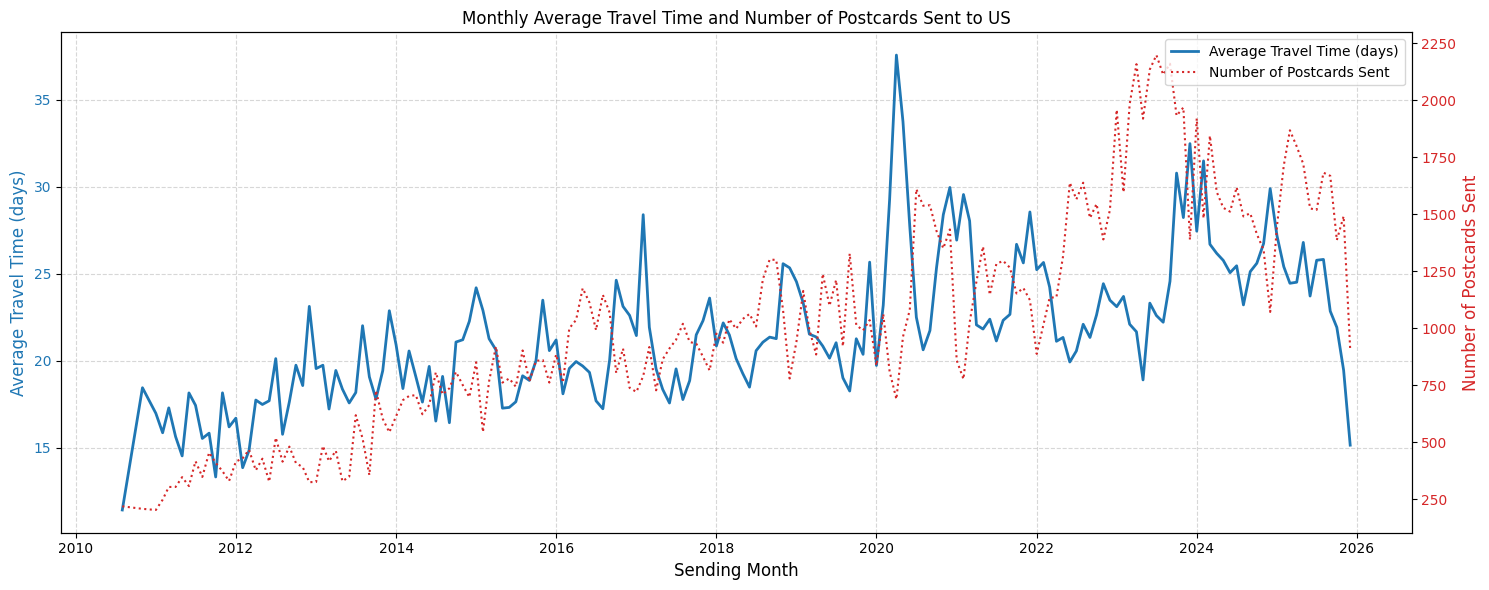

In [69]:
fig, ax1 = plt.subplots(figsize=(15,6))

color1 = "tab:blue"
ax1.set_xlabel("Sending Month", fontsize=12)
ax1.set_ylabel("Average Travel Time (days)", color=color1, fontsize=12)

ax1.plot(monthly_data["sent_month"],
monthly_data["avg_travel_time"],
color=color1,
#marker="o",
linestyle="-",
markersize=5,
linewidth=2,
label="Average Travel Time (days)",
)

ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()

color2 = "tab:red"
ax2.set_ylabel("Number of Postcards Sent", color=color2, fontsize=12)
ax2.plot(monthly_data["sent_month"],
monthly_data["num_postcards_sent"],
color=color2,
#marker="x",
linestyle=":",
linewidth=1.5,
label="Number of Postcards Sent"
)

ax2.tick_params(axis="y", labelcolor=color2)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title("Monthly Average Travel Time and Number of Postcards Sent to US", fontsize=12)
fig.tight_layout()

plt.show();

#### YEAR - Aggregation

In [70]:
df_indexed = df_filtered.set_index('sent_date')

yearly_travel_time = df_indexed['travel_time_days'].resample('YS').mean().reset_index()
yearly_travel_time.columns = ['sent_year', 'avg_travel_time']

yearly_counts = df_indexed['travel_time_days'].resample('YS').size().reset_index(name='num_postcards_sent')
yearly_counts.columns.values[0] = 'sent_year'

yearly_data = pd.merge(yearly_travel_time, yearly_counts, on="sent_year", how="inner")
yearly_data = yearly_data[yearly_data["num_postcards_sent"] > 2400]

yearly_data.head(20)

,sent_year,avg_travel_time,num_postcards_sent
6,2011-01-01,16.186865,4035
7,2012-01-01,17.683491,4973
8,2013-01-01,19.331702,5722
9,2014-01-01,19.396115,8495
10,2015-01-01,20.276849,9507
11,2016-01-01,20.102985,11623
12,2017-01-01,20.771284,10454
13,2018-01-01,21.392380,12730
14,2019-01-01,21.382658,12813
15,2020-01-01,25.953883,14333


#### YEAR - Plot

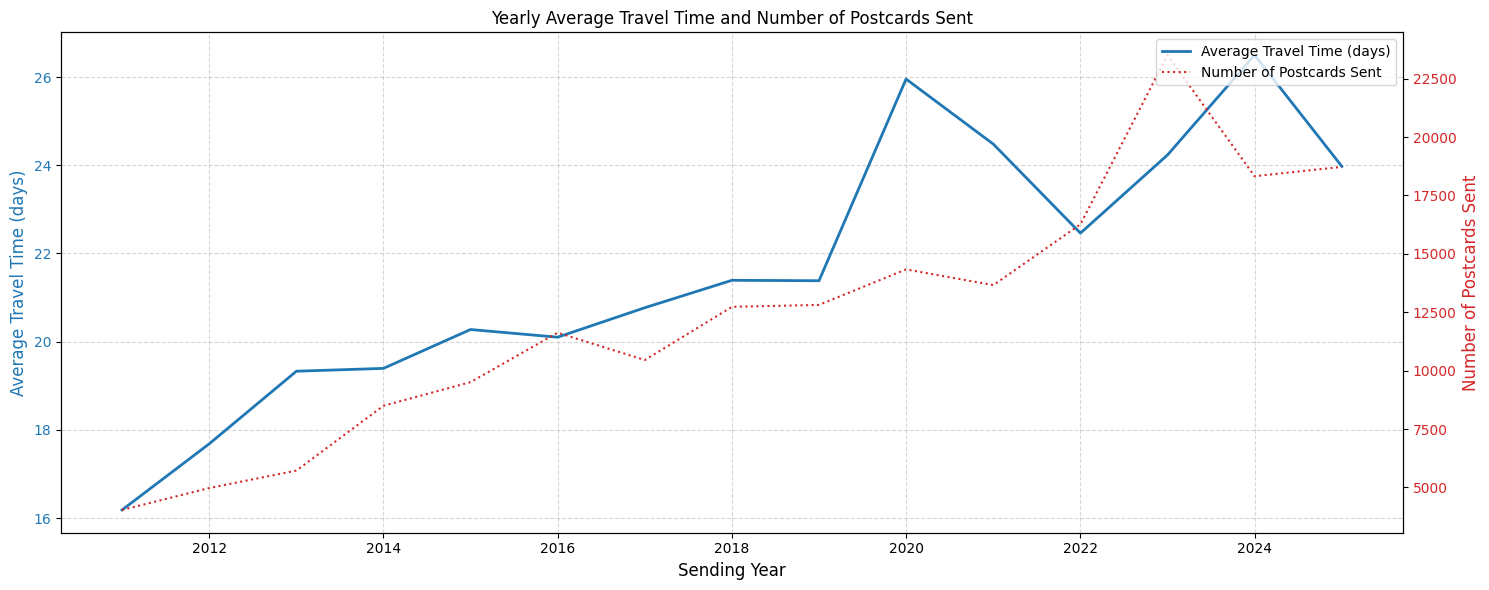

In [71]:
fig, ax1 = plt.subplots(figsize=(15,6))

color1 = "tab:blue"
ax1.set_xlabel("Sending Year", fontsize=12)
ax1.set_ylabel("Average Travel Time (days)", color=color1, fontsize=12)

ax1.plot(yearly_data["sent_year"],
yearly_data["avg_travel_time"],
color=color1,
#marker="o",
linestyle="-",
markersize=5,
linewidth=2,
label="Average Travel Time (days)",
)

ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()

color2 = "tab:red"
ax2.set_ylabel("Number of Postcards Sent", color=color2, fontsize=12)
ax2.plot(yearly_data["sent_year"],
yearly_data["num_postcards_sent"],
color=color2,
#marker="x",
linestyle=":",
linewidth=1.5,
label="Number of Postcards Sent"
)

ax2.tick_params(axis="y", labelcolor=color2)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title("Yearly Average Travel Time and Number of Postcards Sent", fontsize=12)
fig.tight_layout()

plt.show();

#### MONTH per Country - Aggregation

In [88]:
monthly_country_data = df_filtered.groupby([pd.Grouper(key="sent_date", freq="MS"), "country_id_origin"]).agg(
    avg_travel_time=('travel_time_days', 'mean'),
    num_postcards_sent=('travel_time_days', 'size')).reset_index() 

monthly_country_data = monthly_country_data.rename(columns={"sent_date": "month"})
monthly_country_data = monthly_country_data[monthly_country_data["month"] >= pd.Timestamp("2015-12-31")]

print(monthly_country_data.head())

# Filtering only big 5 countries

top_countries = monthly_country_data.groupby("country_id_origin")["num_postcards_sent"].sum().nlargest(7).index

selected_countries = ["DE", "NL", "GB", "FI", "AT", "CA", "US", "CN"]
df_filtered[df_filtered["country_id_origin"].isin(top_countries)].groupby("country_id_origin").size()

          month country_id_origin  avg_travel_time  num_postcards_sent
3852 2016-01-01                AT        17.800000                  40
3853 2016-01-01                AU        27.666667                   3
3854 2016-01-01                BE        17.800000                   5
3855 2016-01-01                BG        21.333333                   3
3856 2016-01-01                BR        31.250000                   4


country_id_origin
AT     9619
CN     5714
DE    34437
FI    13947
NL    14915
RU    19969
US    44651
dtype: int64

##### Germany - Postcards Sent since Nov 2025


In [83]:
country = "Germany"
nationality = "German"
df_de = df_filtered[df_filtered["country_id_origin"] == "DE"]
de_nov25_plus = df_filtered.query("country_id_origin == 'DE' and sent_date >= '2025-11-01' and received_date <= '2026-01-17'")
de_nov25 = df_filtered.query("country_id_origin == 'DE' and sent_date >= '2025-11-01' and sent_date <= '2025-11-30'")
de_dec25 =df_filtered.query("country_id_origin == 'DE' and sent_date >= '2025-12-01' and sent_date <= '2025-12-31'")
de_nov24_plus = df_filtered.query("country_id_origin == 'DE' and sent_date >= '2024-11-01' and sent_date <= '2025-01-17'")
de_nov24_plus_rec20250114 = df_filtered.query("country_id_origin == 'DE' and sent_date >= '2024-11-01' and sent_date <= '2025-01-17' and received_date <= '2025-01-17'")
de_nov24_plus_rec20240114 = df_filtered.query("country_id_origin == 'DE' and sent_date >= '2023-11-01' and sent_date <= '2024-01-17' and received_date <= '2024-01-17'")
de_nov25_deadline = df_filtered.query("country_id_origin == 'DE' and sent_date >= '2025-11-01' and sent_date <= '2025-11-30'")
de_nov24_deadline = df_filtered.query("country_id_origin == 'DE' and sent_date >= '2024-11-01' and sent_date <= '2024-11-30'")
de_nov23_oct24 = df_de.query("sent_date >= '2023-11-01' and sent_date <= '2024-10-31'")
de_nov24_oct25 = df_de.query("sent_date >= '2024-11-01' and sent_date <= '2025-10-31'")
de_dec25_deadline = df_de.query("sent_date >= '2025-12-01' and sent_date <= '2025-12-31'")
de_dec24_deadline = df_de.query("sent_date >= '2024-12-01' and sent_date <= '2024-12-31'")


print(f"So far, only {len(de_nov25_plus)} postcards sent from {country} since November 2025 until Jan 17th have reached the selected US recipients.")
print(f"Among them are {len(de_nov25)} sent in November 2025 and {len(de_dec25)} sent in December 2025.")
print(f"For comparison, in the same period of time in 2024, {len(de_nov24_plus_rec20250114)} {nationality} postcards were received by the selected users.")
print(f"In 2023, the number was {len(de_nov24_plus_rec20240114)}.")
print("------------")
print(f"Sent in Nov25, received until Jan 17th 2026: {len(de_nov25_deadline)}.")
print(f"Sent in Nov24, received until Jan 17th 2024: {len(de_nov24_deadline)}.")
print("------------")
print(f"Sent from Nov23 to Oct24: {len(de_nov23_oct24)}.")
print(f"Sent from Nov24 to Oct25: {len(de_nov24_oct25)}.")
print("------------")
print(f"Sen in Dec25, received until Jan 17th 2026: {len(de_dec25_deadline)}.")
print(f"Sen in Dec24, received until Jan 17th 2024: {len(de_dec24_deadline)}.")

So far, only 69 postcards sent from Germany since November 2025 until Jan 17th have reached the selected US recipients.
Among them are 59 sent in November 2025 and 10 sent in December 2025.
For comparison, in the same period of time in 2024, 322 German postcards were received by the selected users.
In 2023, the number was 465.
------------
Sent in Nov25, received until Jan 17th 2026: 59.
Sent in Nov24, received until Jan 17th 2024: 195.
------------
Sent from Nov23 to Oct24: 2760.
Sent from Nov24 to Oct25: 2496.
------------
Sen in Dec25, received until Jan 17th 2026: 10.
Sen in Dec24, received until Jan 17th 2024: 215.


##### Austria - Postcards Sent since Nov 2025

In [75]:
country = "Austria"
nationality = "Austrian"
at_nov25_plus = df_filtered.query("country_id_origin == 'AT' and sent_date >= '2025-11-01'")
at_nov25 = df_filtered.query("country_id_origin == 'AT' and sent_date >= '2025-11-01' and sent_date <= '2025-11-30'")
at_dec25 = df_filtered.query("country_id_origin == 'AT' and sent_date >= '2025-12-01' and sent_date <= '2025-12-31'")
at_nov24_plus = df_filtered.query("country_id_origin == 'AT' and sent_date >= '2024-11-01' and sent_date <= '2025-01-14'")
at_nov24_plus_rec20250114 = df_filtered.query("country_id_origin == 'AT' and sent_date >= '2024-11-01' and sent_date <= '2025-01-14' and received_date <= '2025-01-14'")
at_nov24_plus_rec20240114 = df_filtered.query("country_id_origin == 'AT' and sent_date >= '2023-11-01' and sent_date <= '2024-01-14' and received_date <= '2024-01-14'")

print(f"So far, {len(at_nov25_plus)} postcards sent from {country} since November 2025 have reached the selected US recipients.")
print(f"Among them are {len(at_nov25)} sent in November 2025 and {len(at_dec25)} sent in December 2025.")
print(f"For comparison, in the same period of time in 2024, {len(at_nov24_plus_rec20250114)} {nationality} postcards were received by these US senders.")
print(f"In 2023, the number was {len(at_nov24_plus_rec20240114)}.")

So far, 27 postcards sent from Austria since November 2025 have reached the selected US recipients.
Among them are 27 sent in November 2025 and 0 sent in December 2025.
For comparison, in the same period of time in 2024, 168 Austrian postcards were received by these US senders.
In 2023, the number was 17.


##### Netherlands - Postcards Sent since Nov 2025

In [76]:
country = "Netherlands"
nationality = "Dutch"
nl_nov25_plus = df_filtered.query("country_id_origin == 'NL' and sent_date >= '2025-11-01'")
nl_nov25 = df_filtered.query("country_id_origin == 'NL' and sent_date >= '2025-11-01' and sent_date <= '2025-11-30'")
nl_dec25 = df_filtered.query("country_id_origin == 'NL' and sent_date >= '2025-12-01' and sent_date <= '2025-12-31'")
nl_nov24_plus = df_filtered.query("country_id_origin == 'NL' and sent_date >= '2024-11-01' and sent_date <= '2025-01-16'")
nl_nov24_plus_rec20250114 = df_filtered.query("country_id_origin == 'NL' and sent_date >= '2024-11-01' and sent_date <= '2025-01-14' and received_date <= '2025-01-14'")
nl_nov24_plus_rec20240114 = df_filtered.query("country_id_origin == 'NL' and sent_date >= '2023-11-01' and sent_date <= '2024-01-14' and received_date <= '2024-01-14'")

print(f"So far, {len(nl_nov25_plus)} postcards sent from {country} since November 2025 have reached the selected US recipients.")
print(f"Among them are {len(nl_nov25)} sent in November 2025 and {len(nl_dec25)} sent in December 2025.")
print(f"For comparison, in the same period of time in 2024, {len(nl_nov24_plus_rec20250114)} {nationality} postcards were received by these US senders.")
print(f"In 2023, the number was {len(nl_nov24_plus_rec20240114)}.")

So far, 153 postcards sent from Netherlands since November 2025 have reached the selected US recipients.
Among them are 89 sent in November 2025 and 64 sent in December 2025.
For comparison, in the same period of time in 2024, 161 Dutch postcards were received by these US senders.
In 2023, the number was 197.


##### France - Postcards Sent since Nov 2025

In [77]:
country = "France"
nationality = "French"
fr_nov25_plus = df_filtered.query("country_id_origin == 'FR' and sent_date >= '2025-11-01'")
fr_nov25 = df_filtered.query("country_id_origin == 'FR' and sent_date >= '2025-11-01' and sent_date <= '2025-11-30'")
fr_dec25 = df_filtered.query("country_id_origin == 'FR' and sent_date >= '2025-12-01' and sent_date <= '2025-12-31'")
fr_nov24_plus = df_filtered.query("country_id_origin == 'FR' and sent_date >= '2024-11-01' and sent_date <= '2025-01-14'")
fr_nov24_plus_rec20250114 = df_filtered.query("country_id_origin == 'FR' and sent_date >= '2024-11-01' and sent_date <= '2025-01-14' and received_date <= '2025-01-14'")
fr_nov24_plus_rec20240114 = df_filtered.query("country_id_origin == 'FR' and sent_date >= '2023-11-01' and sent_date <= '2024-01-14' and received_date <= '2024-01-14'")

print(f"So far, {len(fr_nov25_plus)} postcards sent from {country} since November 2025 have reached the top 5 US senders.")
print(f"Among them are {len(fr_nov25)} sent in November 2025 and {len(fr_dec25)} sent in December 2025.")
print(f"For comparison, in the same period of time in 2024, {len(fr_nov24_plus_rec20250114)} {nationality} postcards were received by these US senders.")
print(f"In 2023, the number was {len(fr_nov24_plus_rec20240114)}.")

So far, 15 postcards sent from France since November 2025 have reached the top 5 US senders.
Among them are 10 sent in November 2025 and 5 sent in December 2025.
For comparison, in the same period of time in 2024, 11 French postcards were received by these US senders.
In 2023, the number was 19.


##### Poland - Postcards Sent since Nov 2025


In [78]:
country = "Poland"
nationality = "Polish"
pl_nov25_plus = df_filtered.query("country_id_origin == 'PL' and sent_date >= '2025-11-01'")
pl_nov25 = df_filtered.query("country_id_origin == 'PL' and sent_date >= '2025-11-01' and sent_date <= '2025-11-30'")
pl_dec25 = df_filtered.query("country_id_origin == 'PL' and sent_date >= '2025-12-01' and sent_date <= '2025-12-31'")
pl_nov24_plus = df_filtered.query("country_id_origin == 'PL' and sent_date >= '2024-11-01' and sent_date <= '2025-01-14'")
pl_nov24_plus_rec20250114 = df_filtered.query("country_id_origin == 'PL' and sent_date >= '2024-11-01' and sent_date <= '2025-01-14' and received_date <= '2025-01-14'")
pl_nov24_plus_rec20240114 = df_filtered.query("country_id_origin == 'PL' and sent_date >= '2023-11-01' and sent_date <= '2024-01-14' and received_date <= '2024-01-14'")

print(f"So far, {len(pl_nov25_plus)} postcards sent from {country} since November 2025 have reached the top 5 US senders.")
print(f"Among them are {len(pl_nov25)} sent in November 2025 and {len(fr_dec25)} sent in December 2025.")
print(f"For comparison, in the same period of time in 2024, {len(pl_nov24_plus_rec20250114)} {nationality} postcards were received by these US senders.")
print(f"In 2023, the number was {len(pl_nov24_plus_rec20240114)}.")

So far, 20 postcards sent from Poland since November 2025 have reached the top 5 US senders.
Among them are 17 sent in November 2025 and 5 sent in December 2025.
For comparison, in the same period of time in 2024, 15 Polish postcards were received by these US senders.
In 2023, the number was 24.


#### MONTH per Country (Travel Time) - Plot

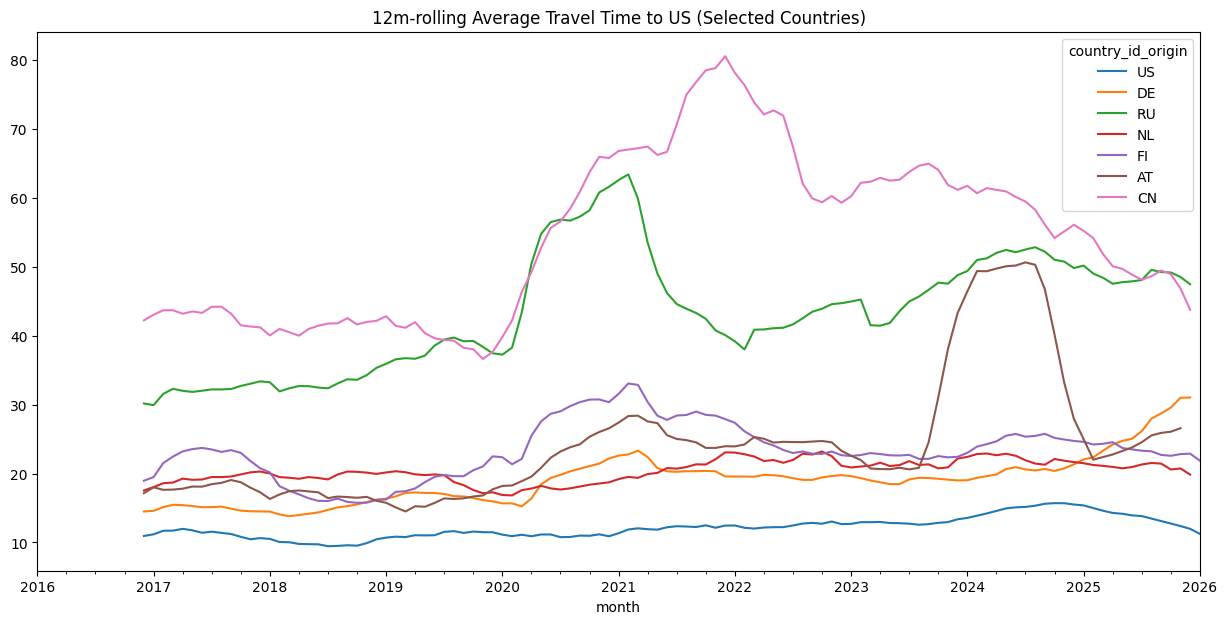

In [91]:
piv_data_m = monthly_country_data.pivot(
    index="month",
    columns="country_id_origin",
    values="avg_travel_time")
    #values="num_postcards_sent")


#piv_data_m[top_countries].plot(figsize=(15,7))
piv_data_m[top_countries].rolling(window=12).mean().plot(figsize=(15,7))
plt.title("12m-rolling Average Travel Time to US (Selected Countries)", fontsize=12)
plt.show();

#### MONTH per Country (Number Sent) - Plot

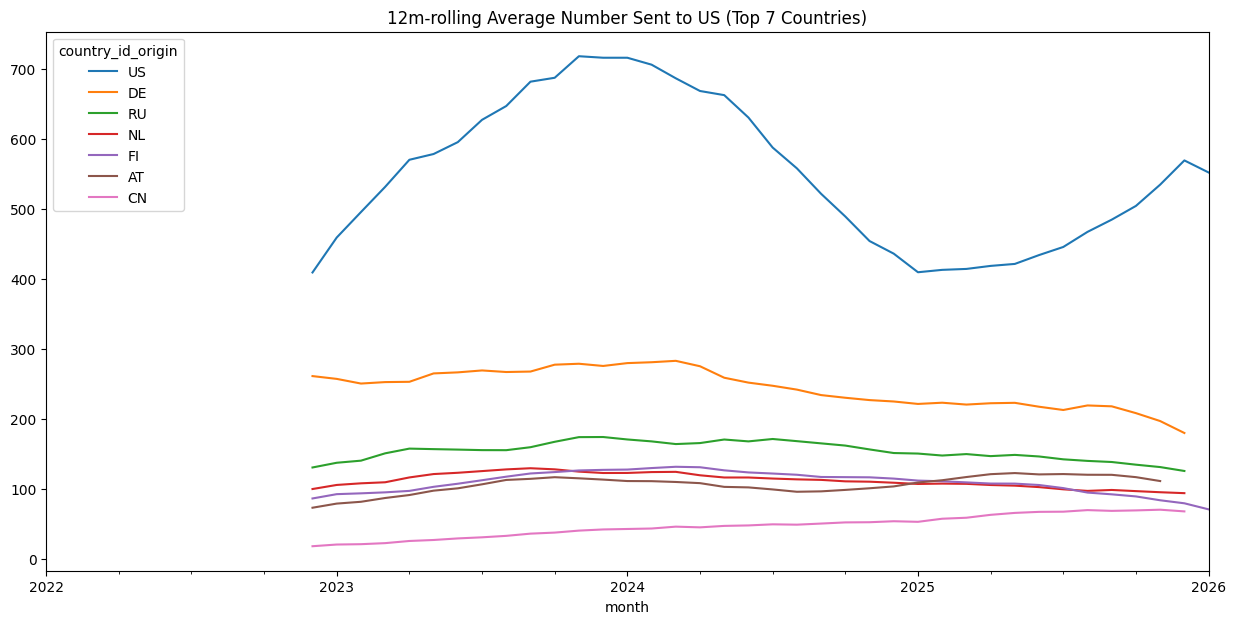

In [87]:
piv_data_m = monthly_country_data.pivot(
    index="month",
    columns="country_id_origin",
    #values="avg_travel_time")
    values="num_postcards_sent")

#piv_data_m[top_countries].plot(figsize=(15,7))
piv_data_m[top_countries].rolling(window=12).mean().plot(figsize=(15,7))
plt.title("12m-rolling Average Number Sent to US (Top 7 Countries)", fontsize=12)
plt.show();

### YEAR per Country - Aggregation

In [80]:
yearly_country_data = df_all.groupby([pd.Grouper(key="sent_date", freq="YE"), "country_id_origin"]).agg(
    avg_travel_time=('travel_time_days', 'mean'),
    num_postcards_sent=('travel_time_days', 'size')).reset_index() 

yearly_country_data = yearly_country_data.rename(columns={"sent_date": "year"})
yearly_country_data = yearly_country_data[yearly_country_data["num_postcards_sent"] > 60]

print(yearly_country_data.head())

# Filtering only big 5 countries

top_countries = yearly_country_data.groupby("country_id_origin")["num_postcards_sent"].sum().nlargest(5).index
print(top_countries)

selected_countries = ["DE", "NL", "GB", "FI", "AT", "CA"]

         year country_id_origin  avg_travel_time  num_postcards_sent
15 2005-12-31                US        10.123288                  73
16 2006-12-31                AT        10.486842                  76
29 2006-12-31                FI        13.870293                 239
56 2006-12-31                US         9.666667                 237
60 2007-12-31                AT         8.718182                 110
Index(['DE', 'US', 'FI', 'NL', 'RU'], dtype='object', name='country_id_origin')


#### YEAR per Country - Plot

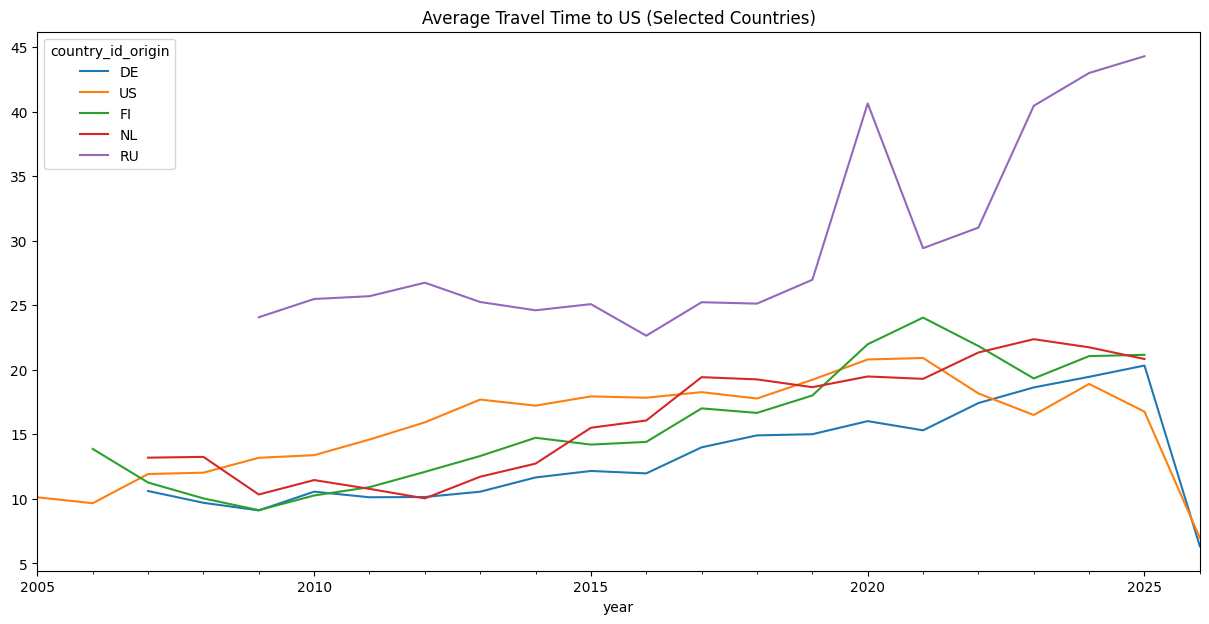

In [81]:
piv_data_y = yearly_country_data.pivot(
    index="year",
    columns="country_id_origin",
    values="avg_travel_time")

piv_data_y[top_countries].plot(figsize=(15,7))
plt.title("Average Travel Time to US (Selected Countries)", fontsize=12)
plt.show();